# 1ª Avaliação Prática – Caminho Mínimo com Dijkstra e Solução Gulosa

**Centro Federal de Educação Tecnológica de Minas Gerais**  
Modelagem Matemática Computacional  
Tópicos em Algoritmos em Grafos  
Prof. Thiago de Souza Rodrigues

---

## Objetivo
O trabalho tem como objetivo o teste e a comparação entre o algoritmo de Dijkstra e uma solução gulosa para obtenção do caminho mínimo em um grafo direcionado ponderado, considerando uma única origem e múltiplos destinos.

## Parte 1 — Dijkstra
  - I. Implementação do algoritmo de Dijkstra para caminho mínimo com origem única e múltiplos destinos.
  - II. Testes do algoritmo:
    - (a) Gerar grafos completos com 4, 5, 6, ..., N vértices, com pesos de arestas estritamente positivos (w > 0).
    - (b) Armazenar cada grafo em uma estrutura de dados escolhida (ex.: lista de adjacência).
    - (c) Aplicar o algoritmo do Item I considerando um vértice qualquer como origem (ex.: 0).
    - (d) Contar o número de comparações realizadas para cada grafo de entrada.
    - (e) Plotar gráfico com Eixo X = número de vértices (n) e Eixo Y = número de comparações.
    - Observação: limitar N a no máximo 1.000.000.
    - (f) Aplicar o algoritmo em duas instâncias (10.000 e 1.000.000 vértices), com origem no vértice 0, e mostrar o número de comparações em cada instância.

## Parte 2 — Heurística Gulosa
  - I. Implementação de uma heurística gulosa para caminho mínimo com origem única e múltiplos destinos.
  - II. Testes do algoritmo:
    - (a) Gerar grafos completos com 4, 5, 6, ..., N vértices, com pesos de arestas estritamente positivos (w > 0).
    - (b) Armazenar cada grafo na mesma estrutura de dados utilizada no Item I.
    - (c) Aplicar a heurística implementada considerando um vértice qualquer como origem (ex.: 0).
    - (d) Contar o número de comparações realizadas para cada grafo de entrada.
    - (e) Plotar gráfico com Eixo X = número de vértices (n) e Eixo Y = número de comparações.
    - Observação: limitar N a no máximo 1.000.000.
    - (f) Aplicar a heurística em duas instâncias (10.000 e 1.000.000 vértices), com origem no vértice 0, e mostrar o número de comparações em cada instância.

---
# PARTE 1 — ALGORITMO DE DIJKSTRA
---

## Parte 1 - I. Implementação do Algoritmo de Dijkstra

Implementação do algoritmo de Dijkstra para caminho mínimo de origem única e múltiplos destinos, com contagem de comparações para análise experimental.

In [10]:
"""
==============================================================================
PARTE 1 - I. IMPLEMENTAÇÃO DO ALGORITMO DE DIJKSTRA (revisado)
==============================================================================
Algoritmo de Dijkstra para caminho mínimo de origem única e múltiplos destinos
com contagem explícita de comparações de relaxamento.

Convenções:
- Grafo direcionado ponderado em lista de adjacência: adj[u] = [(v, peso), ...]
- Pesos devem ser não negativos para a correção do Dijkstra; nos nossos
  experimentos, eles serão estritamente positivos (w > 0) como exigido.
- A contagem de "comparações" se refere ao número de vezes que a condição de
  relaxamento (dist[u] + w < dist[v]) é avaliada (uma por aresta explorada).
"""

import random

from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional
from math import inf
import heapq

import os
from datetime import datetime

def garantir_pasta_saida(pasta: str = "resultados") -> str:
    if not os.path.exists(pasta):
        os.makedirs(pasta, exist_ok=True)
    return pasta


def salvar_tabela_txt(cabecalho: str, linhas: list[tuple], caminho: str) -> None:
    pasta = os.path.dirname(caminho)
    if pasta:
        os.makedirs(pasta, exist_ok=True)
    with open(caminho, 'w', encoding='utf-8') as f:
        f.write(cabecalho.strip() + "\n")
        for row in linhas:
            f.write("\t".join(str(x) for x in row) + "\n")
    print(f"[OK] Tabela salva em: {caminho}")

def timestamp_sufixo() -> str:
    return datetime.now().strftime('%Y%m%d-%H%M%S')
# Tipo para lista de adjacência
type Adj = Dict[int, List[Tuple[int, float]]]

@dataclass
class DijkstraResult:
    dist: Dict[int, float]
    parent: Dict[int, Optional[int]]
    comparisons: int


def _validar_pesos_nao_negativos(adj: Adj) -> None:
    """Levanta ValueError se houver alguma aresta com peso negativo.
    Também alerta se houver peso zero, pois os experimentos pedem w > 0.
    """
    for u, viz in adj.items():
        for v, w in viz:
            if w < 0:
                raise ValueError(
                    f"Dijkstra requer pesos não negativos (aresta {u}->{v} tem peso {w})."
                )


def dijkstra_count(adj: Adj, s: int) -> DijkstraResult:
    """
    Executa Dijkstra com contagem de comparações de relaxamento.

    Parâmetros:
    - adj: grafo em lista de adjacência {u: [(v, peso), ...]}
    - s: vértice de origem (deve existir no grafo)

    Retorna:
    - DijkstraResult(dist, parent, comparisons)

    Observações:
    - Se existirem vértices inalcançáveis a partir de s, suas distâncias serão inf.
    - Complexidade com heap binário: O((V + E) log V)
    """
    if not isinstance(adj, dict) or len(adj) == 0:
        raise ValueError("Grafo vazio ou inválido.")
    if s not in adj:
        raise ValueError(f"Vértice de origem {s} não pertence ao grafo.")

    _validar_pesos_nao_negativos(adj)

    # Inicialização
    dist: Dict[int, float] = {u: inf for u in adj}
    parent: Dict[int, Optional[int]] = {u: None for u in adj}
    dist[s] = 0.0

    # Min-heap de (distância, vértice)
    heap: List[Tuple[float, int]] = [(0.0, s)]
    visited = set()
    comparisons = 0

    while heap:
        du, u = heapq.heappop(heap)
        # Pulo de entradas "obsoletas" no heap
        if du > dist[u]:
            continue
        if u in visited:
            continue
        visited.add(u)

        # Relaxamento das arestas que saem de u
        for v, w in adj[u]:
            comparisons += 1  # contagem da comparação de relaxamento
            if dist[u] + w < dist[v]:
                dist[v] = dist[u] + w
                parent[v] = u
                heapq.heappush(heap, (dist[v], v))

    return DijkstraResult(dist=dist, parent=parent, comparisons=comparisons)


def carregar_grafo_ewd(caminho_arquivo: str) -> Adj:
    """
    Carrega um grafo no formato EWD/Sedgewick (comum em instâncias grandes):
      Linha 1: V (número de vértices)
      Linha 2: E (número de arestas)
      Linhas seguintes: u v w (uma aresta dirigida por linha)
    Retorna um dicionário de listas de adjacência.
    Ignora linhas em branco e comentários (prefixo '#').
    """
    adj: Adj = {}
    with open(caminho_arquivo, "r", encoding="utf-8") as f:
        # Lê V e E
        # Tolerante a espaços/linhas em branco/comentários
        def _proxima_linha_valida() -> str:
            for linha in f:
                linha = linha.strip()
                if not linha or linha.startswith("#"):
                    continue
                return linha
            raise EOFError("Formato EWD inválido: linhas insuficientes.")

        V = int(_proxima_linha_valida())
        E = int(_proxima_linha_valida())
        adj = {i: [] for i in range(V)}

        lidas = 0
        for linha in f:
            linha = linha.strip()
            if not linha or linha.startswith("#"):
                continue
            partes = linha.split()
            if len(partes) < 3:
                continue  # tolerante a linhas quebradas/descrições
            u, v = int(partes[0]), int(partes[1])
            w = float(partes[2])
            adj[u].append((v, w))
            lidas += 1
            if lidas >= E:
                break

    return adj


### (a) Gerar grafos completos com pesos estritamente positivos

Vamos gerar grafos completos com número de vértices variando de 4 até N, atribuindo pesos aleatórios estritamente positivos (w > 0) para cada aresta. O grafo será representado por uma lista de adjacência (`Adj`).

In [11]:
def gerar_grafo_completo(n: int, peso_min: float = 1.0, peso_max: float = 10.0) -> Adj:
    """Gera um grafo completo dirigido com n vértices e pesos estritamente positivos."""
    adj: Adj = {u: [] for u in range(n)}
    for u in range(n):
        for v in range(n):
            if u != v:
                peso = random.uniform(peso_min, peso_max)
                adj[u].append((v, peso))
    return adj

# Exemplo de uso: gerar e exibir um grafo completo pequeno
N_exemplo = 5
grafo_completo = gerar_grafo_completo(N_exemplo)
print(f"Grafo completo com {N_exemplo} vértices:")
for u in grafo_completo:
    print(f"{u}: {[f'{v} (w={w:.2f})' for v, w in grafo_completo[u]]}")

Grafo completo com 5 vértices:
0: ['1 (w=5.79)', '2 (w=8.40)', '3 (w=1.27)', '4 (w=2.55)']
1: ['0 (w=7.79)', '2 (w=9.18)', '3 (w=3.43)', '4 (w=2.69)']
2: ['0 (w=1.94)', '1 (w=5.93)', '3 (w=3.36)', '4 (w=5.81)']
3: ['0 (w=4.79)', '1 (w=4.35)', '2 (w=6.78)', '4 (w=2.11)']
4: ['0 (w=9.37)', '1 (w=9.33)', '2 (w=5.47)', '3 (w=3.41)']


[OK] Imagem salva: resultados/dijkstra/img/grafo_completo_n_5.png


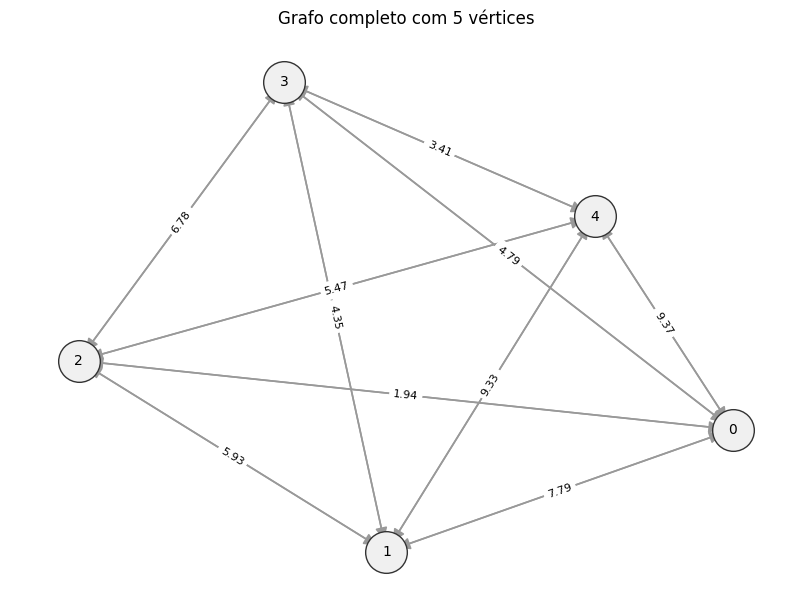

In [12]:
# Visualizar o grafo completo gerado
import matplotlib.pyplot as plt
import networkx as nx
import os


pasta_out = garantir_pasta_saida("resultados/dijkstra/img")
# Construir grafo NetworkX a partir do grafo_completo
G_completo = nx.DiGraph()
for u, viz in grafo_completo.items():
    for v, w in viz:
        G_completo.add_edge(u, v, weight=w)

# Plotar o grafo
fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)
pos = nx.spring_layout(G_completo, seed=42)

# Desenhar nós
nx.draw_networkx_nodes(G_completo, pos, node_color="#f0f0f0", edgecolors="#333", node_size=900, ax=ax)

# Desenhar labels dos nós
node_labels = {v: v for v in G_completo.nodes()}
nx.draw_networkx_labels(G_completo, pos, labels=node_labels, font_size=10, ax=ax)

# Desenhar arestas
nx.draw_networkx_edges(G_completo, pos, edge_color="#999", width=1.2, arrows=True, arrowsize=18, ax=ax)

# Desenhar labels das arestas (pesos)
edge_labels = {(u, v): f"{G_completo[u][v]['weight']:.2f}" for u, v in G_completo.edges()}
nx.draw_networkx_edge_labels(G_completo, pos, edge_labels=edge_labels, font_size=8, ax=ax)

ax.set_title(f"Grafo completo com {N_exemplo} vértices")
ax.set_axis_off()

# Salvar imagem
os.makedirs(pasta_out, exist_ok=True)
fig.savefig(f"{pasta_out}/grafo_completo_n_{N_exemplo}.png", dpi=150)
print(f"[OK] Imagem salva: {pasta_out}/grafo_completo_n_{N_exemplo}.png")

plt.show()

### (b) Armazenar cada grafo em uma estrutura de dados (lista de adjacência)

Para cada valor de n, vamos gerar e armazenar o grafo completo em uma lista de adjacência. Os grafos podem ser guardados em uma lista para uso posterior nos experimentos.

In [13]:
# Parâmetros do experimento
N_min = 4
N_max = 10  # Aumente para valores maiores conforme desejado (ex: 1000, 10000, etc.)

# Lista para armazenar os grafos completos gerados
grafos_completos = []

for n in range(N_min, N_max + 1):
    grafo = gerar_grafo_completo(n)
    grafos_completos.append(grafo)  # Armazena o grafo na lista

print(f"{len(grafos_completos)} grafos completos armazenados (de {N_min} a {N_max} vértices)")

7 grafos completos armazenados (de 4 a 10 vértices)


In [14]:
# Salvar cada grafo completo em arquivo TXT
import os

pasta_out = garantir_pasta_saida("resultados/dijkstra")

for idx, grafo in enumerate(grafos_completos, start=N_min):
    caminho = os.path.join(pasta_out, f"grafo_completo_n{idx}.txt")
    with open(caminho, 'w', encoding='utf-8') as f:
        f.write(f"n={idx}\n")
        for u in sorted(grafo.keys()):
            # Formato: u: v1(peso1), v2(peso2), ...
            linha = f"{u}: " + ", ".join(f"{v}({w:.2f})" for v, w in grafo[u])
            f.write(linha + "\n")
    print(f"[OK] Grafo salvo: {caminho}")

print(f"\n{len(grafos_completos)} grafos salvos em: {pasta_out}")

[OK] Grafo salvo: resultados/dijkstra\grafo_completo_n4.txt
[OK] Grafo salvo: resultados/dijkstra\grafo_completo_n5.txt
[OK] Grafo salvo: resultados/dijkstra\grafo_completo_n6.txt
[OK] Grafo salvo: resultados/dijkstra\grafo_completo_n7.txt
[OK] Grafo salvo: resultados/dijkstra\grafo_completo_n8.txt
[OK] Grafo salvo: resultados/dijkstra\grafo_completo_n9.txt
[OK] Grafo salvo: resultados/dijkstra\grafo_completo_n10.txt

7 grafos salvos em: resultados/dijkstra


### (c) Aplicar o algoritmo de Dijkstra em cada grafo gerado

Para cada grafo completo armazenado, vamos aplicar o algoritmo de Dijkstra considerando o vértice 0 como origem.

In [15]:
# Aplicar Dijkstra em cada grafo completo gerado, usando origem 0
resultados_dijkstra = []  # Lista para armazenar os resultados (distâncias, pais, comparações)

for idx, grafo in enumerate(grafos_completos):
    resultado = dijkstra_count(grafo, s=0)
    resultados_dijkstra.append(resultado)

print(f"Dijkstra aplicado em {len(resultados_dijkstra)} grafos completos (origem = 0)")

Dijkstra aplicado em 7 grafos completos (origem = 0)


In [16]:
# Salvar resultados do Dijkstra (distâncias e pais) em TXT para cada grafo
pasta_out = garantir_pasta_saida("resultados/dijkstra")
for idx, resultado in enumerate(resultados_dijkstra, start=N_min):
    caminho = os.path.join(pasta_out, f"resultado_dijkstra_n{idx}.txt")
    with open(caminho, 'w', encoding='utf-8') as f:
        f.write(f"n={len(resultado.dist)}\n")
        for v in sorted(resultado.dist.keys()):
            dist_str = f"{resultado.dist[v]:.2f}" if resultado.dist[v] != inf else "inf"
            parent_str = str(resultado.parent[v]) if resultado.parent[v] is not None else "None"
            f.write(f"{v}: dist={dist_str}, parent={parent_str}\n")
    print(f"[OK] Resultado salvo: {caminho}")

[OK] Resultado salvo: resultados/dijkstra\resultado_dijkstra_n4.txt
[OK] Resultado salvo: resultados/dijkstra\resultado_dijkstra_n5.txt
[OK] Resultado salvo: resultados/dijkstra\resultado_dijkstra_n6.txt
[OK] Resultado salvo: resultados/dijkstra\resultado_dijkstra_n7.txt
[OK] Resultado salvo: resultados/dijkstra\resultado_dijkstra_n8.txt
[OK] Resultado salvo: resultados/dijkstra\resultado_dijkstra_n9.txt
[OK] Resultado salvo: resultados/dijkstra\resultado_dijkstra_n10.txt


### (d) Contar o número de comparações realizadas para cada grafo de entrada

Vamos extrair o número de comparações realizadas pelo Dijkstra em cada grafo e exibir uma tabela com o número de vértices e o número de comparações.

In [17]:
# Extrair número de vértices e comparações de cada execução
ns = list(range(N_min, N_max + 1))
comparacoes = [res.comparisons for res in resultados_dijkstra]

print("n_vértices\tcomparações")
for n, comp in zip(ns, comparacoes):
    print(f"{n}\t\t{comp}")

n_vértices	comparações
4		12
5		20
6		30
7		42
8		56
9		72
10		90


In [19]:
# Salvar tabela de Dijkstra em TXT
pasta_out = garantir_pasta_saida("resultados/dijkstra")
arquivo_dijkstra = os.path.join(pasta_out, f"dijkstra_comparacoes_{timestamp_sufixo()}.txt")
linhas_dijkstra = list(zip(ns, comparacoes))
salvar_tabela_txt("n\tcomparacoes_dijkstra", linhas_dijkstra, arquivo_dijkstra)

[OK] Tabela salva em: resultados/dijkstra\dijkstra_comparacoes_20251102-145449.txt


### (e) Plotar gráfico: número de vértices (n) vs número de comparações

Vamos plotar o gráfico solicitado, usando Matplotlib, com Eixo X = número de vértices (n) e Eixo Y = número de comparações.

[OK] Gráfico salvo: resultados/dijkstra/img\dijkstra_comparacoes_grafico.png


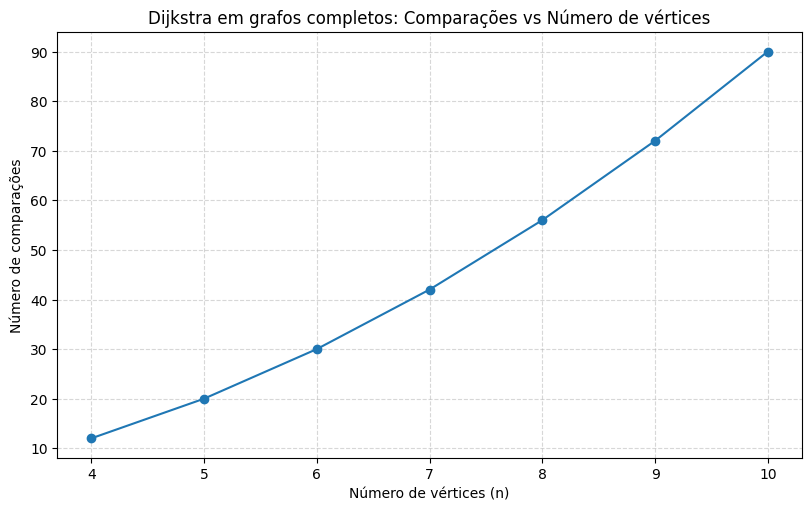

In [20]:
import matplotlib.pyplot as plt
import os

# Plotar gráfico
fig = plt.figure(figsize=(8,5), constrained_layout=True)
plt.plot(ns, comparacoes, marker='o', color='tab:blue')
plt.xlabel('Número de vértices (n)')
plt.ylabel('Número de comparações')
plt.title('Dijkstra em grafos completos: Comparações vs Número de vértices')
plt.grid(True, linestyle='--', alpha=0.5)

# Salvar gráfico
pasta_out = garantir_pasta_saida("resultados/dijkstra/img")
caminho_img = os.path.join(pasta_out, "dijkstra_comparacoes_grafico.png")
fig.savefig(caminho_img, dpi=150, bbox_inches='tight')
print(f"[OK] Gráfico salvo: {caminho_img}")

plt.show()

### (f) Aplicar o algoritmo em duas instâncias grandes (10.000 e 1.000.000 vértices)

Nesta etapa vamos usar as instâncias fornecidas no Moodle (formato EWD):
- "D:\\OneDrive\\Pessoais\\Doutorado\\Cefet\\022025\\Teoria de Grafos\\10000.txt"
- "D:\\OneDrive\\Pessoais\\Doutorado\\Cefet\\022025\\Teoria de Grafos\\largeEWD - contains one million vertices and 15172126 edges.txt"

Origem fixa no vértice 0. Reportaremos o número de comparações e tempos de carga/execução. A execução da instância de 1.000.000 é protegida por flag para evitar travamentos acidentais.

In [21]:
from time import perf_counter
import os

caminho_10k = r"D:\OneDrive\Pessoais\Doutorado\Cefet\022025\Teoria de Grafos\10000.txt"
caminho_1m = r"D:\OneDrive\Pessoais\Doutorado\Cefet\022025\Teoria de Grafos\largeEWD - contains one million vertices and 15172126 edges.txt"


def executar_instancia(caminho: str, origem: int = 0, nome: str | None = None):
    nome = nome or os.path.basename(caminho)
    if not os.path.exists(caminho):
        print(f"[AVISO] Arquivo não encontrado: {caminho}")
        return None
    print(f"\nCarregando {nome}...")
    t0 = perf_counter()
    adj = carregar_grafo_ewd(caminho)
    t1 = perf_counter()
    print(f"Grafo carregado: V={len(adj)} | tempo de carga: {t1 - t0:.2f}s")
    print("Executando Dijkstra (origem=0)...")
    t2 = perf_counter()
    res = dijkstra_count(adj, s=origem)
    t3 = perf_counter()
    print(f"Comparações: {res.comparisons:,} | tempo Dijkstra: {t3 - t2:.2f}s")
    return res

# Executa a instância de 10.000 vértices, se disponível
res_10k = executar_instancia(caminho_10k, origem=0, nome="Instância 10.000")

# Proteção para a instância de 1.000.000 (muito pesada). Altere para True se desejar executar.
RUN_1M = True
if RUN_1M:
    res_1m = executar_instancia(caminho_1m, origem=0, nome="Instância 1.000.000")


Carregando Instância 10.000...
Grafo carregado: V=10000 | tempo de carga: 0.33s
Executando Dijkstra (origem=0)...
Comparações: 123,462 | tempo Dijkstra: 0.12s

Carregando Instância 1.000.000...
Grafo carregado: V=1000000 | tempo de carga: 35.09s
Executando Dijkstra (origem=0)...
Comparações: 15,172,126 | tempo Dijkstra: 20.98s


In [22]:
# Salvar comparações das instâncias grandes de Dijkstra, se executadas
pasta_out = garantir_pasta_saida('resultados/dijkstra')

# Preparar lista de resultados para salvar
resultados_instancias = []

if 'res_10k' in globals() and res_10k is not None:
    resultados_instancias.append(("10k", res_10k.comparisons))
    print(f"Resultado 10k registrado: {res_10k.comparisons:,} comparações")

if 'res_1m' in globals() and res_1m is not None:
    resultados_instancias.append(("1m", res_1m.comparisons))
    print(f"Resultado 1M registrado: {res_1m.comparisons:,} comparações")

# Salvar se houver resultados
if resultados_instancias:
    caminho = os.path.join(pasta_out, f"dijkstra_instancias_{timestamp_sufixo()}.txt")
    salvar_tabela_txt("instancia\tcomparacoes", resultados_instancias, caminho)
else:
    print("[AVISO] Nenhuma instância grande foi executada para salvar.")


Resultado 10k registrado: 123,462 comparações
Resultado 1M registrado: 15,172,126 comparações
[OK] Tabela salva em: resultados/dijkstra\dijkstra_instancias_20251102-145553.txt


---
# PARTE 2 — HEURÍSTICA GULOSA
---

## Parte 2 - I. Implementação da Heurística Gulosa

Heurística escolhida: um único varrimento de relaxamento sobre todas as arestas (ordem fixa da lista de adjacência). É uma aproximação do caminho mínimo por origem única — não garante otimalidade, mas é simples, linear no número de arestas e adequada para comparação experimental. A contagem de comparações corresponde ao número de verificações da condição de relaxamento (dist[u] + w < dist[v]).

In [23]:
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional
from math import inf

# Reutiliza o tipo Adj definido anteriormente neste notebook

@dataclass
class GulosaResult:
    dist: Dict[int, float]
    parent: Dict[int, Optional[int]]
    comparacoes: int


def heuristica_gulosa(adj: Adj, s: int) -> GulosaResult:
    """
    Heurística gulosa: um único varrimento de relaxamento sobre todas as arestas.
    - dist[s] = 0, demais = inf
    - Para cada aresta (u, v, w) em ordem de adjacência, se dist[u] + w < dist[v], atualiza.
    - Contagem de comparações = número de checagens de relaxamento.
    """
    if s not in adj:
        raise ValueError(f"Vértice de origem {s} não pertence ao grafo.")

    dist: Dict[int, float] = {u: inf for u in adj}
    parent: Dict[int, Optional[int]] = {u: None for u in adj}
    dist[s] = 0.0

    comparacoes = 0
    for u in adj:
        for v, w in adj[u]:
            comparacoes += 1
            if dist[u] + w < dist[v]:
                dist[v] = dist[u] + w
                parent[v] = u

    return GulosaResult(dist=dist, parent=parent, comparacoes=comparacoes)

### (a) Gerar grafos completos com pesos estritamente positivos

Vamos gerar grafos completos com número de vértices variando de 4 até N, atribuindo pesos aleatórios estritamente positivos (w > 0) para cada aresta. Reutilizaremos a função `gerar_grafo_completo(n)` já definida na Parte 1.

In [24]:
# Exemplo (Parte 2 - (a)): gerar um grafo completo pequeno
N_exemplo_g2 = 5
ex_grafo_gulosa = gerar_grafo_completo(N_exemplo_g2)
print(f"Grafo completo (heurística) com {N_exemplo_g2} vértices:")
for u in ex_grafo_gulosa:
    print(f"{u}: {[f'{v} (w={w:.2f})' for v, w in ex_grafo_gulosa[u]]}")

Grafo completo (heurística) com 5 vértices:
0: ['1 (w=8.96)', '2 (w=2.93)', '3 (w=7.12)', '4 (w=1.72)']
1: ['0 (w=6.19)', '2 (w=6.22)', '3 (w=8.04)', '4 (w=1.90)']
2: ['0 (w=3.42)', '1 (w=4.72)', '3 (w=9.10)', '4 (w=8.16)']
3: ['0 (w=8.35)', '1 (w=4.80)', '2 (w=4.97)', '4 (w=6.06)']
4: ['0 (w=3.19)', '1 (w=9.18)', '2 (w=2.28)', '3 (w=4.71)']


### (b) Armazenar cada grafo em uma estrutura de dados (lista de adjacência)

Para cada valor de n, vamos gerar e armazenar o grafo completo em uma lista de adjacência (`Adj`) para uso nos experimentos da heurística.

In [25]:
# Exemplo (Parte 2 - (a)): gerar um grafo completo pequeno
N_exemplo_g2 = 5
ex_grafo_gulosa = gerar_grafo_completo(N_exemplo_g2)
print(f"Grafo completo (heurística) com {N_exemplo_g2} vértices:")
for u in ex_grafo_gulosa:
    print(f"{u}: {[f'{v} (w={w:.2f})' for v, w in ex_grafo_gulosa[u]]}")

Grafo completo (heurística) com 5 vértices:
0: ['1 (w=6.39)', '2 (w=1.98)', '3 (w=1.34)', '4 (w=1.75)']
1: ['0 (w=3.18)', '2 (w=5.64)', '3 (w=8.77)', '4 (w=3.02)']
2: ['0 (w=1.92)', '1 (w=4.09)', '3 (w=9.59)', '4 (w=4.62)']
3: ['0 (w=9.88)', '1 (w=8.15)', '2 (w=6.04)', '4 (w=1.87)']
4: ['0 (w=4.35)', '1 (w=6.03)', '2 (w=9.25)', '3 (w=7.43)']


[OK] Imagem salva: resultados/img/gulosa/exemplos/grafo_completo_n5.png


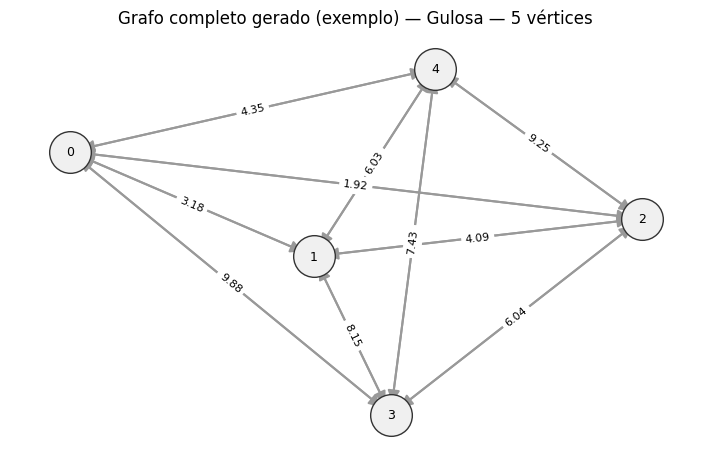

In [26]:
# Visualizar e salvar o grafo completo gerado (Gulosa)
import matplotlib.pyplot as plt
import networkx as nx
import os

# Construir grafo para visualização
G_ex_gulosa = nx.DiGraph()
for u in ex_grafo_gulosa:
    for v, w in ex_grafo_gulosa[u]:
        G_ex_gulosa.add_edge(u, v, weight=w)

fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
pos = nx.spring_layout(G_ex_gulosa, seed=42)
nx.draw_networkx_nodes(G_ex_gulosa, pos, node_color="#f0f0f0", edgecolors="#333", node_size=900, ax=ax)
nx.draw_networkx_labels(G_ex_gulosa, pos, font_size=9, ax=ax)
edge_labels = {(u, v): f"{G_ex_gulosa[u][v]['weight']:.2f}" for u, v in G_ex_gulosa.edges()}
nx.draw_networkx_edges(G_ex_gulosa, pos, edge_color="#999", width=1.5, arrows=True, arrowsize=18, ax=ax)
nx.draw_networkx_edge_labels(G_ex_gulosa, pos, edge_labels=edge_labels, font_size=8, ax=ax)
ax.set_title(f"Grafo completo gerado (exemplo) — Gulosa — {N_exemplo_g2} vértices")
ax.set_axis_off()

# Salvar imagem
os.makedirs("resultados/img/gulosa/exemplos", exist_ok=True)
fig.savefig(f"resultados/img/gulosa/exemplos/grafo_completo_n{N_exemplo_g2}.png", dpi=150)
print(f"[OK] Imagem salva: resultados/img/gulosa/exemplos/grafo_completo_n{N_exemplo_g2}.png")
plt.show()

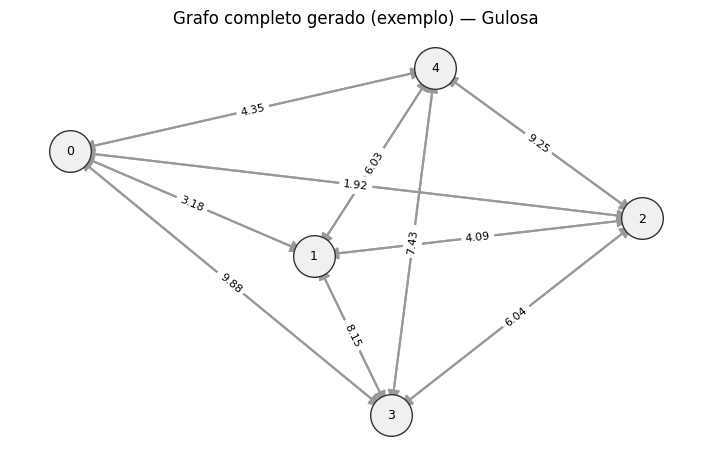

In [27]:
# Plotar e salvar imagem do grafo completo de exemplo (Gulosa)
import matplotlib.pyplot as plt
import networkx as nx
import os

G_ex_gulosa = nx.DiGraph()
for u in ex_grafo_gulosa:
    for v, w in ex_grafo_gulosa[u]:
        G_ex_gulosa.add_edge(u, v, weight=w)
fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
pos = nx.spring_layout(G_ex_gulosa, seed=42)
nx.draw_networkx_nodes(G_ex_gulosa, pos, node_color="#f0f0f0", edgecolors="#333", node_size=900, ax=ax)
nx.draw_networkx_labels(G_ex_gulosa, pos, font_size=9, ax=ax)
edge_labels = {(u, v): f"{G_ex_gulosa[u][v]['weight']:.2f}" for u, v in G_ex_gulosa.edges()}
nx.draw_networkx_edges(G_ex_gulosa, pos, edge_color="#999", width=1.5, arrows=True, arrowsize=18, ax=ax)
nx.draw_networkx_edge_labels(G_ex_gulosa, pos, edge_labels=edge_labels, font_size=8, ax=ax)
ax.set_title("Grafo completo gerado (exemplo) — Gulosa")
ax.set_axis_off()
os.makedirs("resultados/gulosa/img", exist_ok=True)
fig.savefig("resultados/gulosa/img/grafo_completo_exemplo.png", dpi=150)
plt.show()

In [28]:
LIMITE_N = 1_000_000
N_min_gulosa = N_min if 'N_min' in globals() else 4
N_max_gulosa = min((N_max if 'N_max' in globals() else 10), LIMITE_N)

ns_gulosa = list(range(N_min_gulosa, N_max_gulosa + 1))
grafos_gulosa: List[Adj] = []
for n in ns_gulosa:
    grafos_gulosa.append(gerar_grafo_completo(n))
print(f"{len(grafos_gulosa)} grafos completos armazenados para a heurística (de {N_min_gulosa} a {N_max_gulosa} vértices)")

7 grafos completos armazenados para a heurística (de 4 a 10 vértices)


In [29]:
# Salvar grafos completos da Parte 2 (Heurística Gulosa) em arquivos TXT
pasta_out = garantir_pasta_saida("resultados/gulosa")
for idx, grafo in enumerate(grafos_gulosa, start=N_min_gulosa):
    caminho = os.path.join(pasta_out, f"grafo_completo_gulosa_n{idx}.txt")
    with open(caminho, 'w', encoding='utf-8') as f:
        f.write(f"n={idx}\n")
        for u in sorted(grafo.keys()):
            linha = f"{u}: " + ", ".join(f"{v}({w:.2f})" for v, w in grafo[u])
            f.write(linha + "\n")
    print(f"[OK] Grafo salvo: {caminho}")

[OK] Grafo salvo: resultados/gulosa\grafo_completo_gulosa_n4.txt
[OK] Grafo salvo: resultados/gulosa\grafo_completo_gulosa_n5.txt
[OK] Grafo salvo: resultados/gulosa\grafo_completo_gulosa_n6.txt
[OK] Grafo salvo: resultados/gulosa\grafo_completo_gulosa_n7.txt
[OK] Grafo salvo: resultados/gulosa\grafo_completo_gulosa_n8.txt
[OK] Grafo salvo: resultados/gulosa\grafo_completo_gulosa_n9.txt
[OK] Grafo salvo: resultados/gulosa\grafo_completo_gulosa_n10.txt


### (c) Aplicar a heurística em cada grafo gerado

Para cada grafo completo armazenado, vamos aplicar a heurística considerando o vértice 0 como origem.

In [30]:
# Aplicar a heurística em cada grafo completo gerado, usando origem 0
resultados_gulosa: List[GulosaResult] = []  # Lista para armazenar os resultados (distâncias, pais, comparações)

for g in grafos_gulosa:
    r = heuristica_gulosa(g, 0)
    resultados_gulosa.append(r)

print(f"Heurística aplicada em {len(resultados_gulosa)} grafos completos (origem = 0)")

Heurística aplicada em 7 grafos completos (origem = 0)


In [31]:
# Salvar resultados da heurística gulosa (distâncias e pais) em TXT para cada grafo
pasta_out = garantir_pasta_saida("resultados/gulosa")
for idx, resultado in enumerate(resultados_gulosa, start=N_min_gulosa):
    caminho = os.path.join(pasta_out, f"resultado_gulosa_n{idx}.txt")
    with open(caminho, 'w', encoding='utf-8') as f:
        f.write(f"n={len(resultado.dist)}\n")
        for v in sorted(resultado.dist.keys()):
            dist_str = f"{resultado.dist[v]:.2f}" if resultado.dist[v] != inf else "inf"
            parent_str = str(resultado.parent[v]) if resultado.parent[v] is not None else "None"
            f.write(f"{v}: dist={dist_str}, parent={parent_str}\n")
    print(f"[OK] Resultado salvo: {caminho}")

[OK] Resultado salvo: resultados/gulosa\resultado_gulosa_n4.txt
[OK] Resultado salvo: resultados/gulosa\resultado_gulosa_n5.txt
[OK] Resultado salvo: resultados/gulosa\resultado_gulosa_n6.txt
[OK] Resultado salvo: resultados/gulosa\resultado_gulosa_n7.txt
[OK] Resultado salvo: resultados/gulosa\resultado_gulosa_n8.txt
[OK] Resultado salvo: resultados/gulosa\resultado_gulosa_n9.txt
[OK] Resultado salvo: resultados/gulosa\resultado_gulosa_n10.txt


In [32]:
# Extrair número de vértices e comparações de cada execução (heurística)
ns_gulosa = list(range(N_min_gulosa, N_max_gulosa + 1)) if 'N_min_gulosa' in globals() else ns_gulosa
comparacoes_gulosa = [r.comparacoes for r in resultados_gulosa]

print("n_vértices\tcomparações (gulosa)")
for n, c in zip(ns_gulosa, comparacoes_gulosa):
    print(f"{n}\t\t{c}")

n_vértices	comparações (gulosa)
4		12
5		20
6		30
7		42
8		56
9		72
10		90


### (d) Contar o número de comparações realizadas para cada grafo de entrada

Vamos extrair o número de comparações realizadas pela heurística em cada grafo e exibir uma tabela com o número de vértices e o número de comparações.

In [33]:
# Salvar tabela da heurística gulosa em TXT
pasta_out = garantir_pasta_saida("resultados")
arquivo_gulosa = os.path.join(pasta_out, f"gulosa_comparacoes_{timestamp_sufixo()}.txt")
linhas_gulosa = list(zip(ns_gulosa, comparacoes_gulosa))
salvar_tabela_txt("n\tcomparacoes_gulosa", linhas_gulosa, arquivo_gulosa)

[OK] Tabela salva em: resultados\gulosa_comparacoes_20251102-145555.txt


### (e) Plotar gráfico: n (vértices) vs comparações (heurística)  — N ≤ 1.000.000

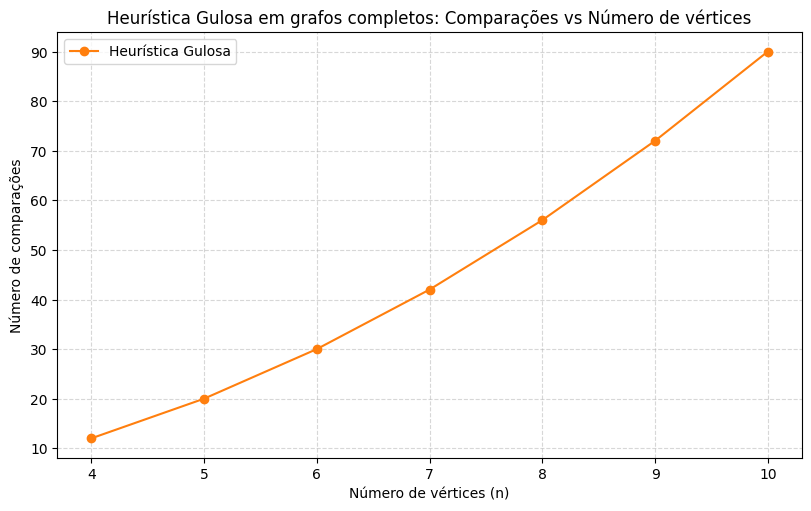

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5), constrained_layout=True)
plt.plot(ns_gulosa, comparacoes_gulosa, marker='o', color='tab:orange', label='Heurística Gulosa')
plt.xlabel('Número de vértices (n)')
plt.ylabel('Número de comparações')
plt.title('Heurística Gulosa em grafos completos: Comparações vs Número de vértices')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

### (f) Instâncias do Moodle — 10.000 e 1.000.000 de vértices (origem = 0) — Heurística Gulosa

In [35]:
from time import perf_counter
import os

caminho_10k = r"D:\OneDrive\Pessoais\Doutorado\Cefet\022025\Teoria de Grafos\10000.txt"
caminho_1m = r"D:\OneDrive\Pessoais\Doutorado\Cefet\022025\Teoria de Grafos\largeEWD - contains one million vertices and 15172126 edges.txt"


def executar_instancia_gulosa(caminho: str, origem: int = 0, nome: str | None = None):
    nome = nome or os.path.basename(caminho)
    if not os.path.exists(caminho):
        print(f"[AVISO] Arquivo não encontrado: {caminho}")
        return None
    print(f"\nCarregando {nome}...")
    t0 = perf_counter()
    adj = carregar_grafo_ewd(caminho)
    t1 = perf_counter()
    print(f"Grafo carregado: V={len(adj)} | tempo de carga: {t1 - t0:.2f}s")
    print("Executando Heurística Gulosa (origem=0)...")
    t2 = perf_counter()
    res = heuristica_gulosa(adj, s=origem)
    t3 = perf_counter()
    print(f"Comparações (gulosa): {res.comparacoes:,} | tempo heurística: {t3 - t2:.2f}s")
    return res

# Executa a instância de 10.000 vértices, se disponível
res_g_10k = executar_instancia_gulosa(caminho_10k, origem=0, nome="Instância 10.000 — Gulosa")

# Proteção para a instância de 1.000.000 (muito pesada). Altere para True se desejar executar.
RUN_1M_GULOSA = False
if RUN_1M_GULOSA:
    res_g_1m = executar_instancia_gulosa(caminho_1m, origem=0, nome="Instância 1.000.000 — Gulosa")


Carregando Instância 10.000 — Gulosa...
Grafo carregado: V=10000 | tempo de carga: 0.21s
Executando Heurística Gulosa (origem=0)...
Comparações (gulosa): 123,462 | tempo heurística: 0.05s


In [36]:
# Salvar comparações das instâncias grandes (heurística), se executadas
if 'res_g_10k' in globals() and res_g_10k is not None:
    pasta_out = garantir_pasta_saida('resultados')
    caminho = os.path.join(pasta_out, f"gulosa_instancias_{timestamp_sufixo()}.txt")
    salvar_tabela_txt("instancia\tcomparacoes_gulosa", [("10k", res_g_10k.comparacoes)], caminho)

[OK] Tabela salva em: resultados\gulosa_instancias_20251102-145556.txt
